# Gradient Boosting Model: XGBoost (Numerical + Demographic Features)

### Settings

In [17]:
# Settings

import os
import json
import pandas as pd
import numpy as np
import torch
import optuna
import joblib
from pathlib import Path
from copy import deepcopy
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, fbeta_score, f1_score, recall_score, precision_score, precision_recall_curve, auc, average_precision_score
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix


PREFIX = 'xgboost_num_dem_'
SEED = 1234
TUNE = True
TUNE_PROB = True
TUNE_SAVE = True
TUNE_METRIC = 'prauc' # recall/auc/f1/f2/prauc
TUNE_OUTPUT = PREFIX + f'params_{TUNE_METRIC}.json'
TUNE_LOG_OUTPUT = PREFIX + f'log_{TUNE_METRIC}.csv'
TUNE_PROB_OUTPUT = PREFIX + f'prob_{TUNE_METRIC}.json'
MODEL_OUTPUT = PREFIX + f'model_{TUNE_METRIC}.json'
MODEL_LOAD = False
MODEL_SAVE = True
N_TRIALS = 150

### Load data

In [18]:
# Load data
X_train, X_val, X_test, y_train, y_val, y_test = DataLoader().fetch_data(version='final_label')

# Select columns
num_cols = [
    'pipeline_standard__time_in_hospital',
    'pipeline_standard__num_lab_procedures',
    'pipeline_standard__num_procedures',
    'pipeline_standard__num_medications',
    'pipeline_standard__number_outpatient',
    'pipeline_standard__number_emergency',
    'pipeline_standard__number_inpatient',
    'pipeline_standard__number_diagnoses'
]
dem_cols = [
    'pipeline_label__race',
    'pipeline_label__gender',
    'pipeline_label__age'
]
X_train = X_train[num_cols + dem_cols]
X_val   = X_val[num_cols + dem_cols]
X_test  = X_test[num_cols + dem_cols]

# Convert categorical columns type
cat_cols = [c for c in X_train.columns if c not in num_cols]
X_train[cat_cols] = X_train[cat_cols].astype('category')
X_val[cat_cols]   = X_val[cat_cols].astype('category')
X_test[cat_cols]  = X_test[cat_cols].astype('category')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/y_test.csv 
Data imported succesfully from paths


### Hyperparameter tuning

In [19]:
# Define objective function
fixed_params = {
    'objective'         : 'binary:logistic',
    'eval_metric'       : 'logloss',
    'tree_method'       : 'hist',
    'device'            : 'cuda',
    'enable_categorical': True,
    'random_state'      : SEED,
    'n_jobs'            : -1,
}

# Log container
log_opt = list()

def objective(trial):
    """
    Hyperparameter tuning objective function.

    Args:
        trial: Tuning hyperparameter trial

    Returns:
        Assessment score
    """
    params = {
        'n_estimators'    : 6000,
        'max_depth'       : trial.suggest_int('max_depth'         , 6    , 12),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1  , 100  , log = True),
        'subsample'       : trial.suggest_float('subsample'       , 0.2  , 1.0),
        'learning_rate'   : trial.suggest_float('learning_rate'   , 0.005, 0.2  , log = True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2  , 1.0),
        'gamma'           : trial.suggest_float('gamma'           , 0    , 10),
        'reg_alpha'       : trial.suggest_float('reg_alpha'       , 0.001, 10   , log = True),
        'reg_lambda'      : trial.suggest_float('reg_lambda'      , 0.001, 10   , log = True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8  , 1.2),
    }
    params.update(fixed_params)

    # Fit the model
    model = XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(X_train,
              y_train,
              eval_set=[(X_val, y_val)],
              verbose=False
              )
    trial.set_user_attr('best_iteration', model.best_iteration)

    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val = accuracy_score(y_val, y_pred_val)
    if acc_train - acc_val > 0.10:  # >10% gap suggests overfitting
        print(f"Warning: Possible overfitting")
        return 0

    recall = recall_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    accuracy = accuracy_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_prob_val)
    prauc = average_precision_score(y_val, y_prob_val)
    f1 = f1_score(y_val, y_pred_val)
    f2 = fbeta_score(y_val, y_pred_val, beta=2)

    match TUNE_METRIC:
        case 'recall':
            score = recall
        case 'f1':
            score = f1
        case 'f2':
            score = f2
        case 'auc':
            score = roc_auc
        case 'prauc':
            score = prauc

    trial_params = trial.params
    trial_params['n_estimators'] = model.best_iteration
    print(f'Trial: {trial.number} - Score ({TUNE_METRIC}): {score} | Recall: {recall} | Precision: {precision} | Accuracy: {accuracy} | ROC-AUC: {roc_auc} | F1: {f1} | F2: {f2} | Parameters: {trial_params}')

    # Log detail
    dict_perf = {
        'trial': trial.number,
        'prauc': prauc,
        'recall': recall,
        'precision': precision,
        'accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'F1': f1,
        'F2': f2,
    }
    dict_perf.update(trial_params)
    log_opt.append(dict_perf)

    return score


def log_callback(study, trial):
    """
    Optuner logging callback.
    """
    print(f'Best trial: {study.best_trial.number} | Score: {study.best_value}\n')

In [20]:
if TUNE:

    # Perform tuning and save the best parameters
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1, callbacks=[log_callback])

    # Get best parameters
    best_params = study.best_params
    best_params['n_estimators'] = study.best_trial.user_attrs.get('best_iteration') + 1
    print('Best Trial:', study.best_trial.number)
    print('Best Value:', study.best_value)
    print('Best Parameters:', best_params)

    # Create log dataframe
    df_log = pd.DataFrame(log_opt).sort_values(by=['trial'])
    df_log['n_estimators'] = df_log['n_estimators'] + 1
    df_log['best_trial'] = df_log['trial'] == study.best_trial.number

    if TUNE_SAVE:

        # Save params
        print('Parameters saved to:', TUNE_OUTPUT)
        with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'w') as f:
            json.dump(best_params, f)

        # Save log
        df_log.to_csv(os.path.join(os.getcwd(), TUNE_LOG_OUTPUT), index=False)

Trial: 12 - Score (prauc): 0.6484963619779494 | Recall: 0.3928228132008971 | Precision: 0.6712903814564701 | Accuracy: 0.6232321707182042 | ROC-AUC: 0.6710474603253316 | F1: 0.4956205363158604 | F2: 0.42836178984882717 | Parameters: {'max_depth': 12, 'min_child_weight': 0.13990256064259673, 'subsample': 0.9689840345919498, 'learning_rate': 0.1826607524066323, 'colsample_bytree': 0.5446613433734938, 'gamma': 9.744135688345093, 'reg_alpha': 0.3603084702520071, 'reg_lambda': 0.03897985322004874, 'scale_pos_weight': 0.8336509563299673, 'n_estimators': 67}
Best trial: 12 | Score: 0.6484963619779494

Trial: 1 - Score (prauc): 0.649126068772722 | Recall: 0.5664851009291894 | Precision: 0.6173902921662204 | Accuracy: 0.6302783230157532 | ROC-AUC: 0.6730874901814801 | F1: 0.5908432661245405 | F2: 0.575983319940056 | Parameters: {'max_depth': 9, 'min_child_weight': 3.889233518088468, 'subsample': 0.6262312796771582, 'learning_rate': 0.13716067751478725, 'colsample_bytree': 0.5756545323808103, 'g

### Probability threshold tuning

In [21]:
def tune_prob_th(best_params, min_recall=0.8):
    """
    Probability threshold tuning by maximizing precision for a given recall threshold.
    """
    final_params = deepcopy(fixed_params)
    final_params.update(best_params)
    print('Final params:', final_params)

    # Fit the model
    model = XGBClassifier(**final_params)
    model.fit(X_train,
              y_train,
              )
    y_prob = model.predict_proba(X_val)[:, 1]
    precision, recall, th = precision_recall_curve(y_val, y_prob)

    # remove extra endpoint w/o th
    precision = precision[:-1]
    recall = recall[:-1]

    # Get thresholds above min recall
    idx_r = np.flatnonzero(recall > min_recall)
    max_p = np.max(precision[idx_r])
    idx_best_th = idx_r[np.isclose(precision[idx_r], max_p, rtol=1e-10, atol=1e-10)]
    best_th = th[idx_best_th[np.argmax(th[idx_best_th])]]

    return float(best_th)

# Tune probability threshold
if TUNE_PROB:

    # Load tuned parameters
    with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'r') as f:
        best_params = json.load(f)

    # Tune probability threshold
    best_th = tune_prob_th(best_params)

    if TUNE_SAVE:

        # Save output
        print('Parameters saved to:', TUNE_PROB_OUTPUT)
        with open(os.path.join(os.getcwd(), TUNE_PROB_OUTPUT), 'w') as f:
            json.dump({'best_th': best_th}, f)

Final params: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'tree_method': 'hist', 'device': 'cuda', 'enable_categorical': True, 'random_state': 1234, 'n_jobs': -1, 'max_depth': 12, 'min_child_weight': 10.404796242204391, 'subsample': 0.3645803897916915, 'learning_rate': 0.006691521989779188, 'colsample_bytree': 0.7530072188046245, 'gamma': 3.4909976149530886, 'reg_alpha': 2.081288994557931, 'reg_lambda': 0.18871203497818337, 'scale_pos_weight': 1.0599204066356085, 'n_estimators': 1277}
Parameters saved to: xgboost_num_dem_prob_prauc.json


### Model training with the best parameters

In [22]:
# Load parameters
with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'r') as f:
    best_params = json.load(f)

final_params = deepcopy(fixed_params)
final_params.update(best_params)
final_params.update({'device': 'cpu'})

# Fit model
if not MODEL_LOAD:

    # Fit the model
    model = XGBClassifier(**final_params)
    model.fit(X_train,
              y_train,
              )

    # Save model
    if MODEL_SAVE:
        joblib.dump(model, os.path.join(os.getcwd(), MODEL_OUTPUT))

# Load model
else:
    model = joblib.load(os.path.join(os.getcwd(), MODEL_OUTPUT))

# Get model performance
y_prob_val = model.predict_proba(X_val)[:, 1]
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

recall = recall_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
accuracy = accuracy_score(y_val, y_pred_val)
roc_auc = roc_auc_score(y_val, y_prob_val)
prauc = average_precision_score(y_val, y_prob_val)
f1 = f1_score(y_val, y_pred_val)
f2 = fbeta_score(y_val, y_pred_val, beta=2)

print(f'PRAUC: {prauc} | Recall: {recall} | Precision: {precision} | Accuracy: {accuracy} | ROC-AUC: {roc_auc} | F1: {f1} | F2: {f2} | Parameters: {final_params}')

PRAUC: 0.650232245725672 | Recall: 0.5318808074335148 | Precision: 0.622655663915979 | Accuracy: 0.6275101917560019 | ROC-AUC: 0.6731831211874291 | F1: 0.5736996716778987 | F2: 0.5478547854785478 | Parameters: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'tree_method': 'hist', 'device': 'cpu', 'enable_categorical': True, 'random_state': 1234, 'n_jobs': -1, 'max_depth': 12, 'min_child_weight': 10.404796242204391, 'subsample': 0.3645803897916915, 'learning_rate': 0.006691521989779188, 'colsample_bytree': 0.7530072188046245, 'gamma': 3.4909976149530886, 'reg_alpha': 2.081288994557931, 'reg_lambda': 0.18871203497818337, 'scale_pos_weight': 1.0599204066356085, 'n_estimators': 1277}


### Performance assessment

Probability threshold: 0.39841708540916443
### Train results ###
              precision    recall  f1-score   support

           0       0.71      0.40      0.51     31515
           1       0.55      0.82      0.66     28090

    accuracy                           0.60     59605
   macro avg       0.63      0.61      0.58     59605
weighted avg       0.63      0.60      0.58     59605

f1: 0.6559503907868605
recall: 0.8171591313634745
precision: 0.5478673890732033
accuracy: 0.5960238235047395




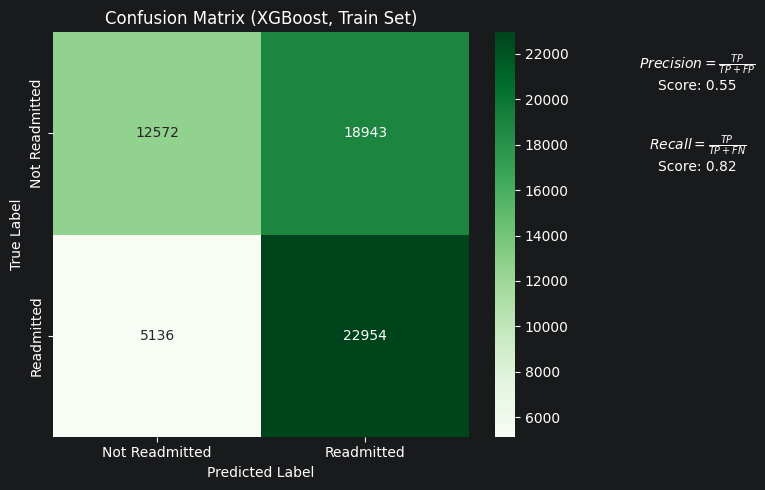

### Validation results ###
              precision    recall  f1-score   support

           0       0.69      0.40      0.51     10506
           1       0.54      0.80      0.65      9363

    accuracy                           0.59     19869
   macro avg       0.62      0.60      0.58     19869
weighted avg       0.62      0.59      0.57     19869

f1: 0.646232328909256
recall: 0.798248424650219
precision: 0.5428529924462522
accuracy: 0.5881523982082641




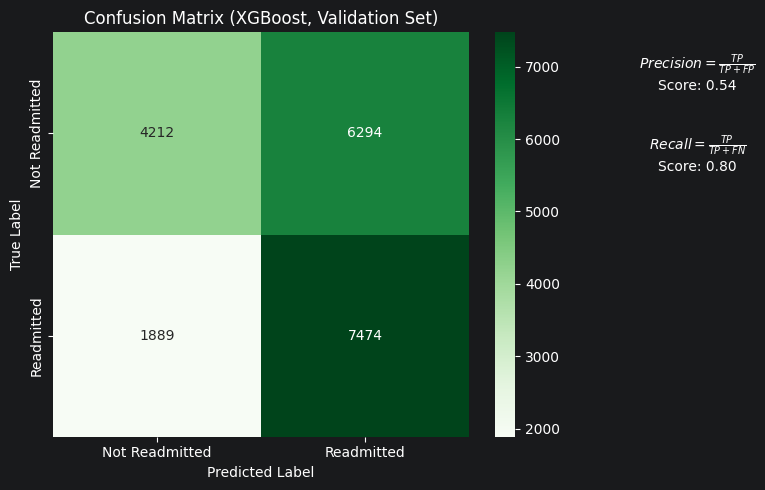

### Test results ###
              precision    recall  f1-score   support

           0       0.70      0.40      0.51     10506
           1       0.55      0.81      0.65      9363

    accuracy                           0.59     19869
   macro avg       0.62      0.60      0.58     19869
weighted avg       0.63      0.59      0.58     19869

f1: 0.6502543761317582
recall: 0.8054042507743244
precision: 0.5452244956980695
accuracy: 0.5917258040163068




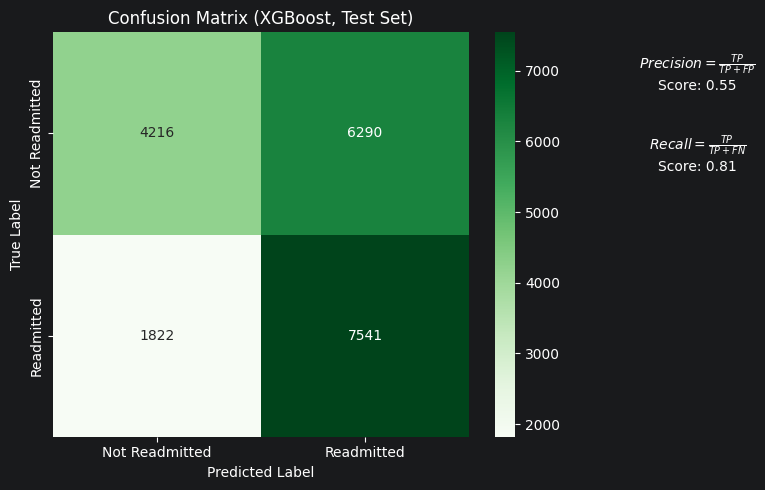

In [23]:
# Load prob threshold
with open(os.path.join(os.getcwd(), TUNE_PROB_OUTPUT), 'r') as f:
    best_th = json.load(f)['best_th']

print('Probability threshold:', best_th)

# Predict outcomes
y_pred_train = (model.predict_proba(X_train)[:, 1] >= best_th) * 1
y_pred_val = (model.predict_proba(X_val)[:, 1] >= best_th) * 1
y_pred_test = (model.predict_proba(X_test)[:, 1] >= best_th) * 1

# Train results
print('### Train results ###')
recall, precision, f1, acc,  cl_report = \
evaluate_predictions(true_values=y_train,
                     predictions=y_pred_train,
                     print_class_report=True)
print('f1:', f1)
print('recall:', recall)
print('precision:', precision)
print('accuracy:', acc)
print('\n')
results_cm_train = plot_confusion_matrix(y_train,
                                         y_pred_train,
                                         class_names=['Not Readmitted', 'Readmitted'],
                                         fig_size=(8,5),
                                         title='Confusion Matrix (XGBoost, Train Set)',
                                         colour_map='Greens'
                                         )

# Validation results
print('### Validation results ###')
recall, precision, f1, acc,  cl_report = \
evaluate_predictions(true_values=y_val,
                     predictions=y_pred_val,
                     print_class_report=True)
print('f1:', f1)
print('recall:', recall)
print('precision:', precision)
print('accuracy:', acc)
print('\n')
results_cm_val = plot_confusion_matrix(y_val,
                                       y_pred_val,
                                       class_names=['Not Readmitted', 'Readmitted'],
                                       fig_size=(8,5),
                                       title='Confusion Matrix (XGBoost, Validation Set)',
                                       colour_map='Greens'
                                       )

# Test results
print('### Test results ###')
recall, precision, f1, acc,  cl_report = \
evaluate_predictions(true_values=y_test,
                     predictions=y_pred_test,
                     print_class_report=True)
print('f1:', f1)
print('recall:', recall)
print('precision:', precision)
print('accuracy:', acc)
print('\n')
results_cm_test = plot_confusion_matrix(y_test,
                                        y_pred_test,
                                        class_names=['Not Readmitted', 'Readmitted'],
                                        fig_size=(8,5),
                                        title='Confusion Matrix (XGBoost, Test Set)',
                                        colour_map='Greens'
                                        )

### Feature importance

<Axes: title={'center': 'Total Gain'}>

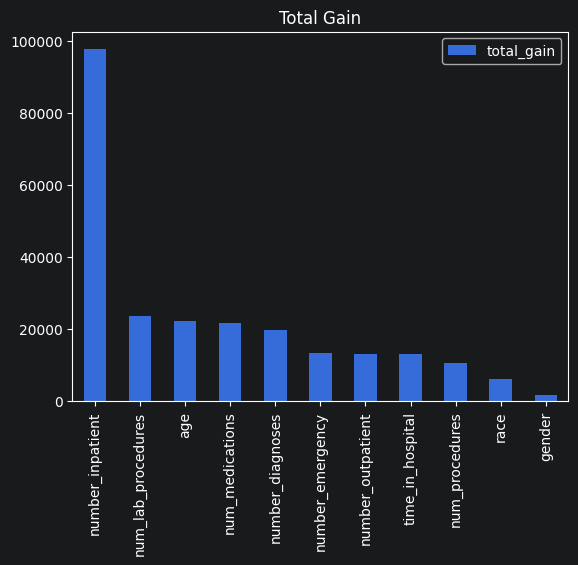

In [24]:
# Get feature importance
dict_imp = {
    'gain': model.get_booster().get_score(importance_type='gain'),
    'total_gain': model.get_booster().get_score(importance_type='total_gain'),
    'weight': model.get_booster().get_score(importance_type='weight'),
    'cover': model.get_booster().get_score(importance_type='cover'),
    'total_cover': model.get_booster().get_score(importance_type='total_cover'),
}
df_imp = pd.concat([pd.DataFrame(v, index=[k]).T for k, v in dict_imp.items()], axis=1).sort_values('total_gain', ascending=False)
df_imp.index = [c.split('__')[1] for c in df_imp.index]

# Plot feature importance
df_imp[['total_gain']].head(20).plot(kind='bar',
                                     title='Total Gain',
                                     )
